# Options Trading: Greeks, Structures & Volatility Strategies

A practical, simulation-driven tour of vanilla options. Every concept is paired
with a Black-Scholes engine you can poke at: change strikes, vol, time, and watch
the Greeks and P&L surface respond.

**Section map**

| # | Topic |
|---|---|
| 0 | Setup & Black-Scholes engine |
| 1 | The Greeks: unified reference |
| 2 | Single legs: long/short call & put |
| 3 | Vertical spreads (4 flavors) |
| 4 | Butterflies & condors (incl. iron variants) |
| 5 | Calendar spreads & diagonals |
| 6 | Risk reversals & seagulls (skew/hedging) |
| 7 | Volatility strategies: straddles, strangles |
| 8 | Higher-order Greeks: charm, vanna, vomma, speed, color |
| 9 | Delta-hedging & gamma P&L decomposition |
| 10 | Choosing a structure for a given view |

**Conventions used throughout:** spot `S`, strike `K`, time-to-expiry `T` in years,
vol `sigma` annualized, risk-free `r`, continuous dividend `q`. Positions are
expressed as a list of legs `(qty, type, K, T, sigma)` so you can recombine
anything. Long positive qty, short negative.


## 0. Setup & Black-Scholes engine

Closed-form BS with continuous dividend yield, plus the full Greek pack including
the higher-order ones (charm, vanna, vomma, speed, color, zomma, ultima).

All Greeks here are **per option**, scaled to natural units:
- delta: dV/dS (no scaling)
- gamma: d²V/dS² (no scaling — multiply by S²/100 for "gamma $ per 1% move")
- vega: dV/dsigma per **1.00 vol point** — divide by 100 for "per vol-point" in % terms
- theta: dV/dT in **years** — divide by 365 for daily theta
- charm = -dDelta/dT (delta decay per year)
- vanna = dDelta/dsigma = dVega/dS
- vomma (volga) = d²V/dsigma²


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm
from dataclasses import dataclass
from typing import Literal, List, Tuple

plt.rcParams.update({
    "figure.figsize": (10, 5),
    "figure.dpi": 110,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

N  = norm.cdf
n_ = norm.pdf

def _d1d2(S, K, T, r, q, sigma):
    T = np.maximum(T, 1e-12)
    sigma = np.maximum(sigma, 1e-12)
    d1 = (np.log(S/K) + (r - q + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))
    d2 = d1 - sigma*np.sqrt(T)
    return d1, d2

def bs_price(S, K, T, r, q, sigma, cp="C"):
    d1, d2 = _d1d2(S, K, T, r, q, sigma)
    if cp == "C":
        return S*np.exp(-q*T)*N(d1) - K*np.exp(-r*T)*N(d2)
    else:
        return K*np.exp(-r*T)*N(-d2) - S*np.exp(-q*T)*N(-d1)

def greeks(S, K, T, r, q, sigma, cp="C"):
    """Return a dict of Greeks. cp = 'C' or 'P'."""
    d1, d2 = _d1d2(S, K, T, r, q, sigma)
    sgn = 1 if cp == "C" else -1
    sqrtT = np.sqrt(np.maximum(T, 1e-12))
    disc_q = np.exp(-q*T)
    disc_r = np.exp(-r*T)
    pdf_d1 = n_(d1)

    delta = sgn * disc_q * N(sgn*d1)
    gamma = disc_q * pdf_d1 / (S * sigma * sqrtT)
    vega  = S * disc_q * pdf_d1 * sqrtT                       # per 1.00 vol
    theta = (-S*disc_q*pdf_d1*sigma/(2*sqrtT)
             - sgn*r*K*disc_r*N(sgn*d2)
             + sgn*q*S*disc_q*N(sgn*d1))                      # per year
    rho   = sgn * K * T * disc_r * N(sgn*d2)

    # second order
    vanna = -disc_q * pdf_d1 * d2 / sigma                      # dDelta/dsigma
    vomma = vega * d1 * d2 / sigma                             # dVega/dsigma
    charm = (-disc_q * pdf_d1 *
             (2*(r - q)*T - d2*sigma*sqrtT) / (2*T*sigma*sqrtT)
             + sgn*q*disc_q*N(sgn*d1))                         # dDelta/dT (math), sign by convention
    # third order
    speed = -gamma/S * (d1/(sigma*sqrtT) + 1)                  # dGamma/dS
    color = (-disc_q * pdf_d1 / (2*S*T*sigma*sqrtT) *
             (2*q*T + 1 + (2*(r-q)*T - d2*sigma*sqrtT)*d1/(sigma*sqrtT)))   # dGamma/dT
    zomma = gamma * (d1*d2 - 1) / sigma                        # dGamma/dsigma

    return dict(price=bs_price(S,K,T,r,q,sigma,cp),
                delta=delta, gamma=gamma, vega=vega, theta=theta, rho=rho,
                vanna=vanna, vomma=vomma, charm=charm,
                speed=speed, color=color, zomma=zomma)

# ---- Position abstraction: a list of legs, each (qty, cp, K, T, sigma) ----
@dataclass
class Leg:
    qty: float
    cp:  Literal["C", "P"]
    K:   float
    T:   float
    sigma: float

def pos_price(legs: List[Leg], S, r=0.04, q=0.0):
    return sum(L.qty * bs_price(S, L.K, L.T, r, q, L.sigma, L.cp) for L in legs)

def pos_greeks(legs: List[Leg], S, r=0.04, q=0.0):
    out = {}
    for L in legs:
        g = greeks(S, L.K, L.T, r, q, L.sigma, L.cp)
        for k, v in g.items():
            out[k] = out.get(k, 0.0) + L.qty * v
    return out

# Quick sanity test
print("ATM 1y 20% call price:", round(bs_price(100, 100, 1.0, 0.04, 0, 0.2, "C"), 4))
print("ATM 1y 20% call delta:", round(greeks(100, 100, 1.0, 0.04, 0, 0.2, "C")["delta"], 4))


ATM 1y 20% call price: 9.9251
ATM 1y 20% call delta: 0.6179


## 1. The Greeks: unified reference

Before structures, build intuition for what each Greek **looks like** as a
function of spot. We plot delta, gamma, vega, theta, vanna, charm for an ATM
1-year 20-vol call. Patterns to internalize:

- **Delta** is an S-curve from 0 to 1; ATM ~ 0.5 (slightly above with positive carry).
- **Gamma** is bell-shaped, peaked at-the-money, **highest near expiry**.
- **Vega** is bell-shaped like gamma, but peak migrates and it is **highest for long-dated**.
- **Theta** is most negative ATM, and accelerates as T → 0.
- **Vanna** is positive for OTM calls / ITM puts, negative for ITM calls / OTM puts — it's the *skew transmission belt*: a vol move tilts the delta curve.
- **Charm** tells you how delta bleeds over time — important for **overnight hedging**.


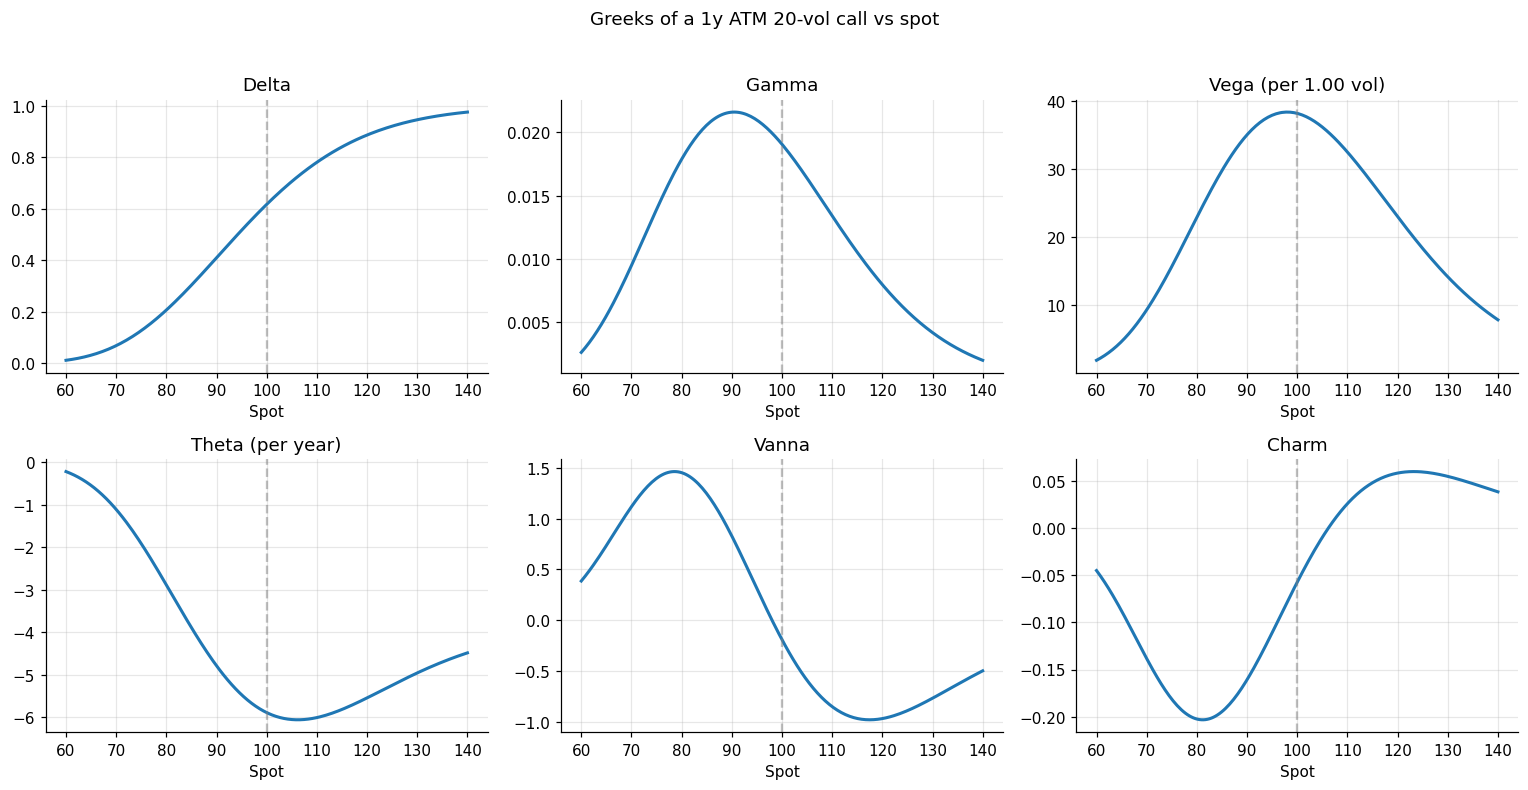

In [2]:
S_grid = np.linspace(60, 140, 200)
K, T, r, q, sigma = 100, 1.0, 0.04, 0.0, 0.20

g_call = [greeks(S, K, T, r, q, sigma, "C") for S in S_grid]
df = pd.DataFrame(g_call)
df["S"] = S_grid

fig, axes = plt.subplots(2, 3, figsize=(14, 7))
specs = [("delta","Delta"),("gamma","Gamma"),("vega","Vega (per 1.00 vol)"),
         ("theta","Theta (per year)"),("vanna","Vanna"),("charm","Charm")]
for ax, (key, name) in zip(axes.flat, specs):
    ax.plot(df["S"], df[key], lw=2)
    ax.axvline(K, color="grey", ls="--", alpha=0.5)
    ax.set_title(name); ax.set_xlabel("Spot")
plt.suptitle("Greeks of a 1y ATM 20-vol call vs spot", y=1.02)
plt.tight_layout(); plt.show()


**Vega and gamma look similar but aren't the same animal.**

Gamma and vega both peak near ATM but they live on different time scales:

- **Short-dated options** have huge gamma, small vega (not enough time for vol changes to matter much).
- **Long-dated options** have small gamma, huge vega.

This is why calendars and diagonals exist — you can be long one and short the other.


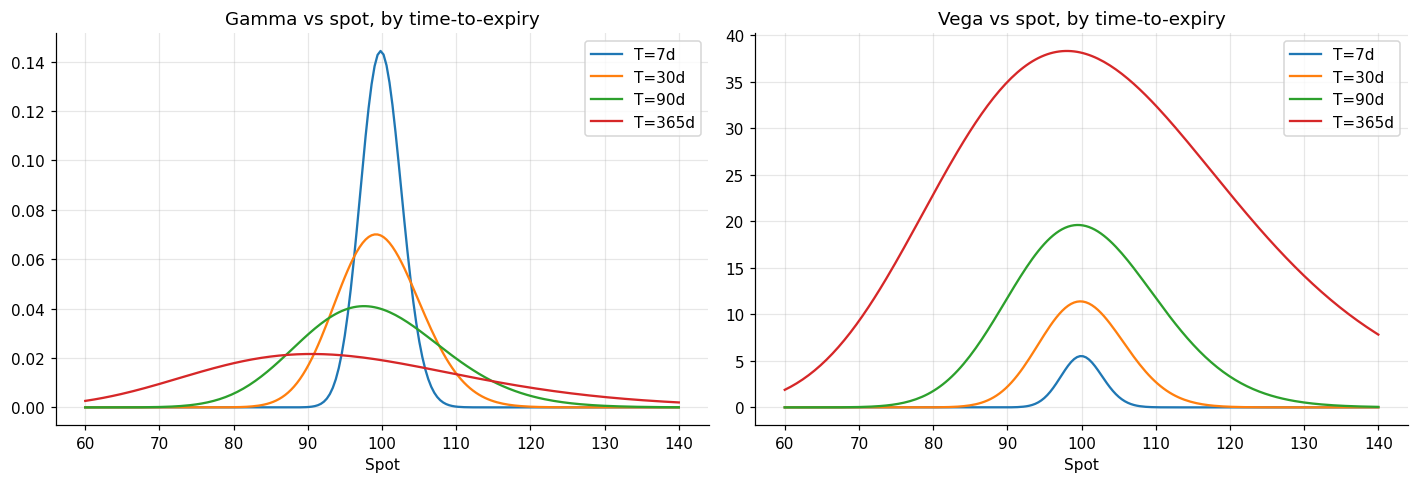

In [3]:
Ts = [7/365, 30/365, 90/365, 365/365]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 4.5))
for T_ in Ts:
    gv = [greeks(S, 100, T_, r, q, sigma, "C") for S in S_grid]
    a1.plot(S_grid, [x["gamma"] for x in gv], label=f"T={int(T_*365)}d")
    a2.plot(S_grid, [x["vega"]  for x in gv], label=f"T={int(T_*365)}d")
a1.set_title("Gamma vs spot, by time-to-expiry"); a1.set_xlabel("Spot"); a1.legend()
a2.set_title("Vega vs spot, by time-to-expiry");  a2.set_xlabel("Spot"); a2.legend()
plt.tight_layout(); plt.show()


## 2. Single legs: long/short call & put

Helper: plot a position's P&L (vs spot, at multiple times-to-expiry) and the
Greek profile at current `T`. We'll reuse it for every structure.


In [4]:
def plot_structure(legs, S0=100, S_range=(60,140), r=0.04, q=0.0, title=""):
    S_grid = np.linspace(*S_range, 200)
    # P&L at multiple Ts, holding everything else constant. T scales by ratio.
    T_orig = legs[0].T
    Ts_frac = [1.0, 0.5, 0.25, 1e-6]  # full life, half, quarter, expiry
    labels  = ["t=0 (now)", "halfway", "near expiry", "at expiry"]

    cost = pos_price(legs, S0, r, q)

    fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

    for f, lab in zip(Ts_frac, labels):
        scaled = [Leg(L.qty, L.cp, L.K, max(L.T*f, 1e-9), L.sigma) for L in legs]
        pnl = np.array([pos_price(scaled, S, r, q) for S in S_grid]) - cost
        axes[0].plot(S_grid, pnl, label=lab, lw=2 if f==1e-6 else 1.2,
                     ls="-" if f==1e-6 else "--", alpha=1 if f==1e-6 else 0.7)
    axes[0].axhline(0, color="k", lw=0.6)
    axes[0].axvline(S0, color="grey", ls=":", alpha=0.6)
    axes[0].set_title(f"{title} — P&L vs spot")
    axes[0].set_xlabel("Spot at evaluation"); axes[0].set_ylabel("P&L")
    axes[0].legend()

    # Greek profile right now
    gks = ["delta","gamma","vega","theta","vanna","charm"]
    rows = [pos_greeks(legs, S, r, q) for S in S_grid]
    for k in gks:
        axes[1].plot(S_grid, [row[k] for row in rows], label=k)
    axes[1].axvline(S0, color="grey", ls=":", alpha=0.6)
    axes[1].axhline(0, color="k", lw=0.6)
    axes[1].set_title(f"{title} — Greeks vs spot (now)")
    axes[1].set_xlabel("Spot"); axes[1].legend(ncol=3, fontsize=9)
    plt.tight_layout(); plt.show()

    # Print summary at S0
    g0 = pos_greeks(legs, S0, r, q)
    print(f"At S={S0}: cost={cost:+.3f}  "
          f"delta={g0['delta']:+.3f}  gamma={g0['gamma']:+.4f}  "
          f"vega={g0['vega']:+.3f}  theta={g0['theta']:+.3f}  "
          f"vanna={g0['vanna']:+.4f}  charm={g0['charm']:+.4f}")


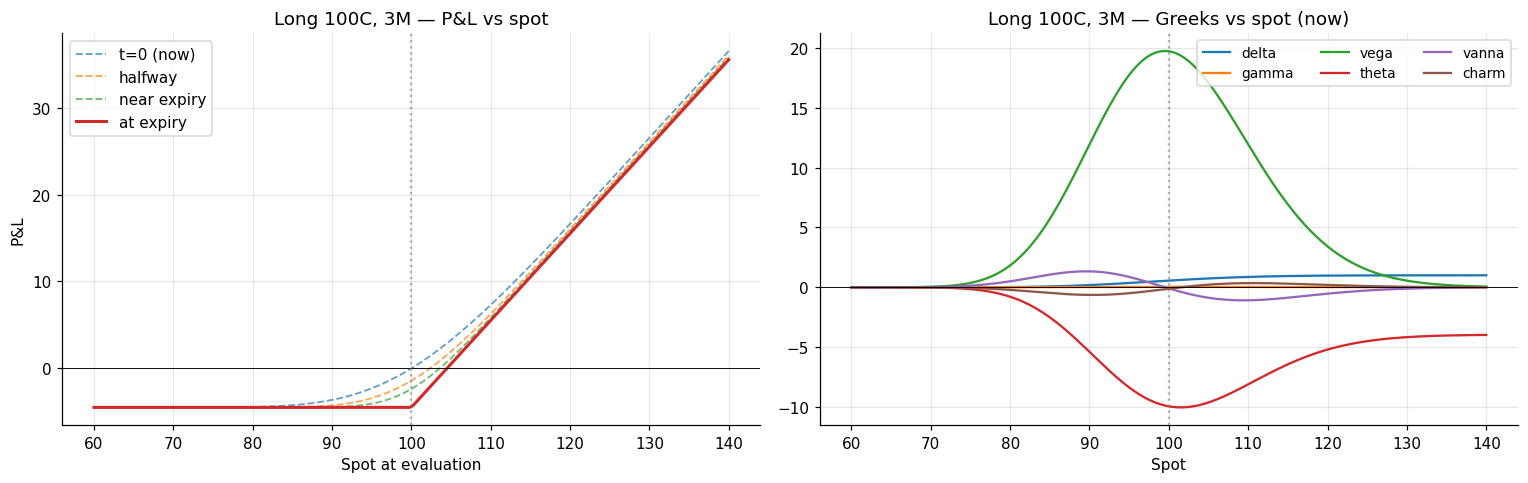

At S=100: cost=+4.485  delta=+0.560  gamma=+0.0394  vega=+19.724  theta=-9.949  vanna=-0.0986  charm=-0.1183


In [5]:
# Long ATM call
plot_structure([Leg(+1, "C", 100, 0.25, 0.20)], title="Long 100C, 3M")


**Long call mental model**: limited loss (premium paid), unlimited upside,
positive delta, positive gamma, positive vega, **negative theta**. Note the gamma
profile peaks ATM — being long gamma means you make money on movement
(realized vol > implied), but you bleed theta to own it.


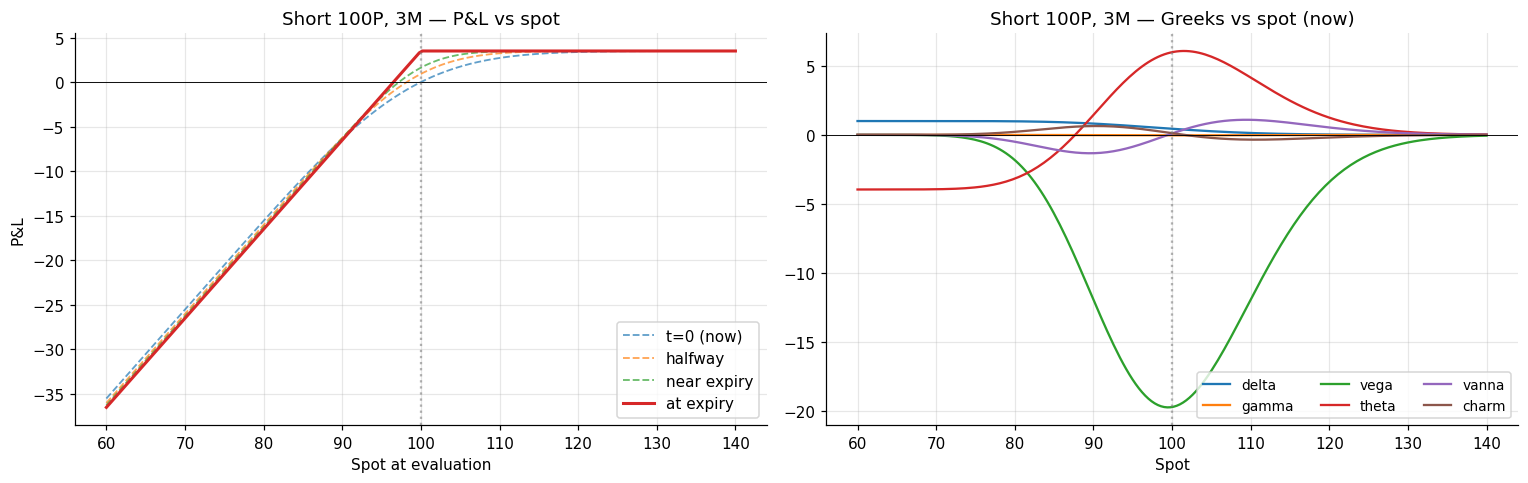

At S=100: cost=-3.490  delta=+0.440  gamma=-0.0394  vega=-19.724  theta=+5.988  vanna=+0.0986  charm=+0.1183


In [6]:
# Short ATM put
plot_structure([Leg(-1, "P", 100, 0.25, 0.20)], title="Short 100P, 3M")


**Short put vs long call — same delta sign, different risk shape.** Both are
bullish-delta, but short put is *long carry, short tail*: you collect premium and
theta, but eat unlimited downside (well, limited to K → 0). This is the classic
"picking up nickels in front of a steamroller" payoff. Negative gamma, negative
vega — you lose if anything moves much or if implied vol pops.


## 3. Vertical spreads

Four flavors, same skeleton: buy one strike, sell another, same expiry.

| Name | Structure | View | Premium |
|---|---|---|---|
| **Bull call** | Long lower-K call, short higher-K call | Moderately bullish | Debit |
| **Bear put**  | Long higher-K put,  short lower-K put  | Moderately bearish | Debit |
| **Bull put**  | Short higher-K put, long lower-K put   | Mildly bullish     | Credit |
| **Bear call** | Short lower-K call, long higher-K call | Mildly bearish     | Credit |

Debit spreads (bull call / bear put) **want movement** to the target; credit
spreads (bull put / bear call) **want stagnation/drift** with the short strike
expiring OTM. Same payoff diagram in pairs — what changes is whether you pay or
collect premium, which flips the **theta** sign at inception.


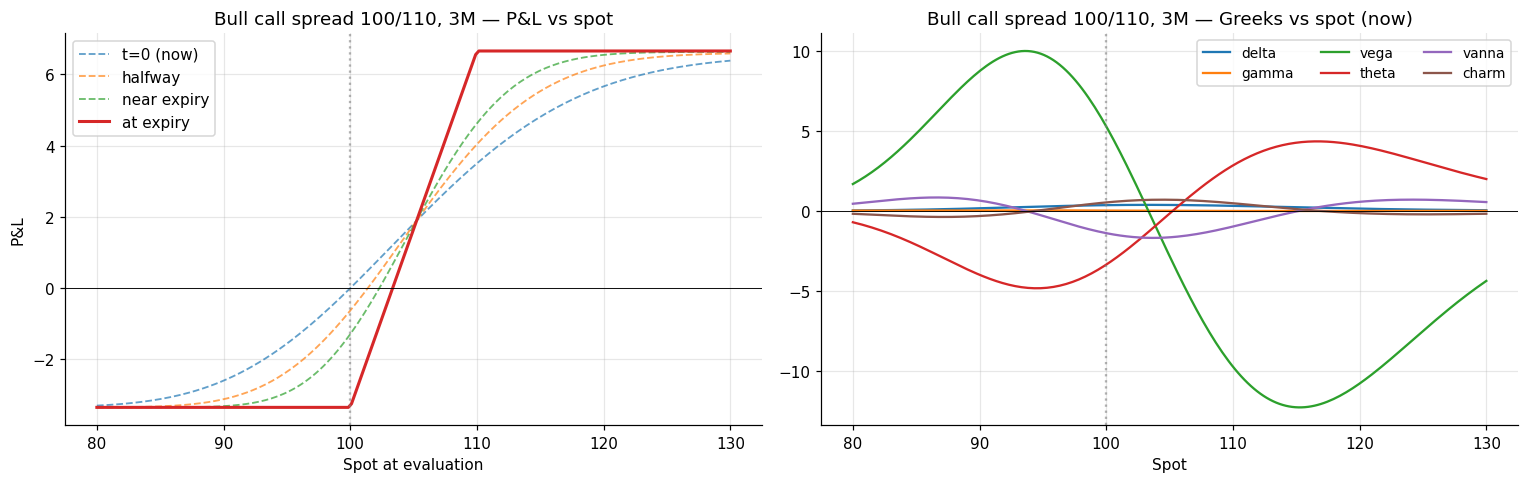

At S=100: cost=+3.345  delta=+0.349  gamma=+0.0106  vega=+5.275  theta=-3.371  vanna=-1.4035  charm=+0.5192


In [7]:
# Bull call spread: long 100C, short 110C (3M, 20 vol)
plot_structure([Leg(+1, "C", 100, 0.25, 0.20),
                Leg(-1, "C", 110, 0.25, 0.20)],
               S_range=(80, 130), title="Bull call spread 100/110, 3M")


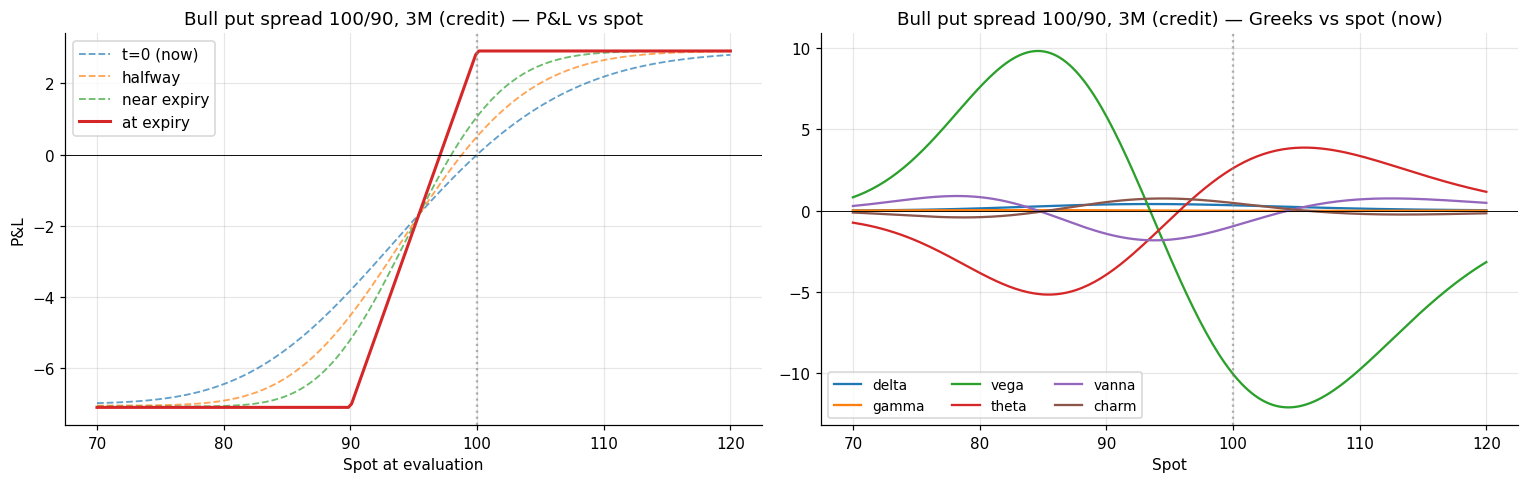

At S=100: cost=-2.909  delta=+0.326  gamma=-0.0201  vega=-10.057  theta=+2.602  vanna=-0.9683  charm=+0.4678


In [8]:
# Bull put spread: short 100P, long 90P (3M)
plot_structure([Leg(-1, "P", 100, 0.25, 0.20),
                Leg(+1, "P",  90, 0.25, 0.20)],
               S_range=(70, 120), title="Bull put spread 100/90, 3M (credit)")


**Notice the Greek profiles for the two bullish spreads are nearly identical**
— this is put-call parity at work. The choice between debit and credit is a
**vol/skew expression**, not a directional one:

- Debit (bull call): you're *paying* for direction. Better when IV is low.
- Credit (bull put): you're *receiving* premium. Better when IV is high. You also
  pick up theta from day 1.

If put-skew is rich (puts overpriced vs calls), selling puts (bull put) is
mechanically better than buying calls (bull call) for the same bullish view.


## 4. Butterflies & condors

Butterflies and condors are **pinning bets** — you collect max payoff if spot
lands at a specific point (fly) or within a band (condor) at expiry.

Long fly: `+1 K1, -2 K2, +1 K3` (K1<K2<K3, K2 = midpoint). Cheap, defined risk,
positive convexity around the center, **negative gamma** between the wings (you
*want* it to stop moving).

Iron variants use both calls and puts to net out a credit instead of a debit but
have an identical P&L diagram.


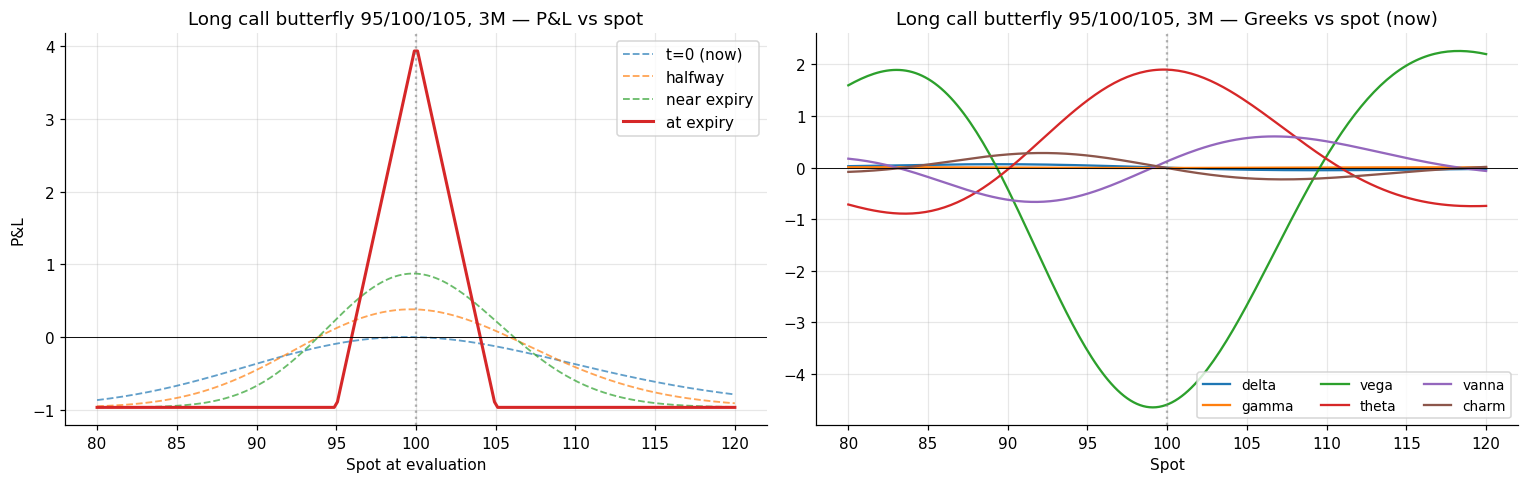

At S=100: cost=+0.966  delta=-0.005  gamma=-0.0092  vega=-4.596  theta=+1.898  vanna=+0.1209  charm=-0.0116


In [9]:
# Long call butterfly 95/100/105
plot_structure([Leg(+1, "C",  95, 0.25, 0.20),
                Leg(-2, "C", 100, 0.25, 0.20),
                Leg(+1, "C", 105, 0.25, 0.20)],
               S_range=(80, 120), title="Long call butterfly 95/100/105, 3M")


Look at the gamma profile — it's **negative** at the body and **positive**
at the wings. This is the signature of a fly: you're short gamma where the fly
pays max, long gamma at the wings as protection. Vega is small and changes sign
around the strikes — flies are a **pure pin bet**, not a vol bet.

A long fly is also a **short realized-vol** trade with capped loss. If you're
short a straddle, your loss is unbounded; a fly caps it at the wing distance.


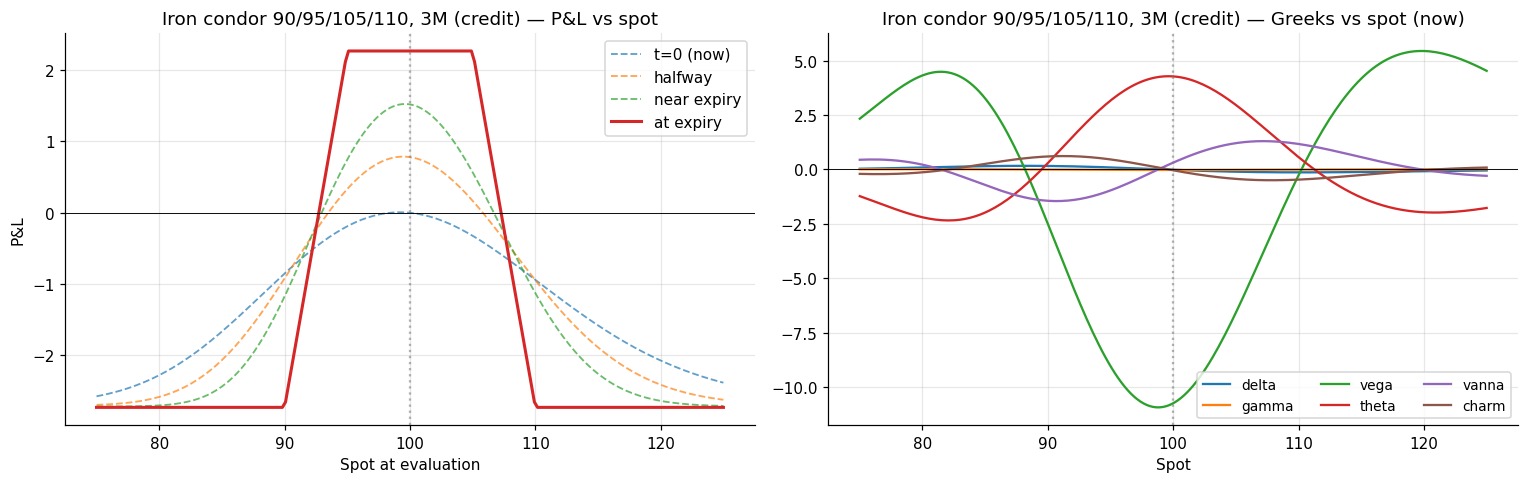

At S=100: cost=-2.270  delta=-0.017  gamma=-0.0215  vega=-10.736  theta=+4.274  vanna=+0.3143  charm=-0.0398


In [10]:
# Iron condor: short 95P / long 90P / short 105C / long 110C
plot_structure([Leg(+1, "P",  90, 0.25, 0.20),
                Leg(-1, "P",  95, 0.25, 0.20),
                Leg(-1, "C", 105, 0.25, 0.20),
                Leg(+1, "C", 110, 0.25, 0.20)],
               S_range=(75, 125), title="Iron condor 90/95/105/110, 3M (credit)")


Iron condor — the bread and butter of "I want to collect theta in a sideways
market" trades. **Negative gamma** (you lose if it moves), **negative vega** (you
lose if IV pops), **positive theta** (you earn time decay). The risk you're
*really* taking is short realized vol with wings as crash protection.

Common professional sizing: pick short strikes around 15-20 delta, wings 5-10
delta out. Max loss = wing width minus credit received.


## 5. Calendar spreads & diagonals

Now we leave the single-expiry world. **Calendar = same strike, different
expiries**. **Diagonal = different strike *and* different expiry**.

The economics: short-dated options have more **gamma and theta** per unit
premium; long-dated options have more **vega**. A long calendar (sell front,
buy back) is therefore:

- **Short gamma** (the front option's gamma > back's at ATM)
- **Long vega** (the back option's vega dominates)
- **Positive theta** initially (front decays faster)
- A bet that the **term structure of IV stays elevated or steepens** — i.e. a
  bet that long-dated IV rises *or* short-dated IV stays put

Critical: a calendar spread is also a **pinning bet on the front strike** at
front expiry. If spot drifts far from K by the front's expiry, the front goes
to zero and you're just left long the back option — directional exposure
appears.


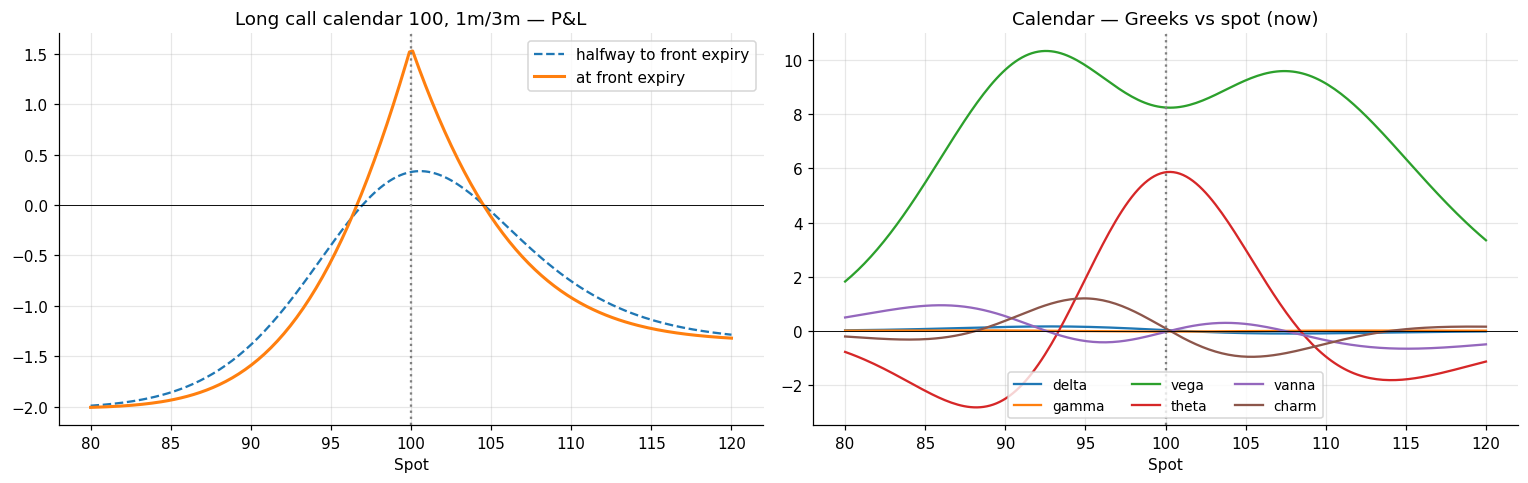

Net premium paid: 2.0159
Greeks at S=100: {'delta': np.float64(0.0251), 'gamma': np.float64(-0.0294), 'vega': np.float64(8.2506), 'theta': np.float64(5.8586), 'vanna': np.float64(-0.0413), 'charm': np.float64(0.0882)}


In [11]:
# Long ATM call calendar: sell 1M 100C, buy 3M 100C
# Note: we use different T's per leg
legs_cal = [Leg(-1, "C", 100, 1/12, 0.20),
            Leg(+1, "C", 100, 3/12, 0.20)]

S_grid = np.linspace(80, 120, 200)
# P&L at front expiry: front leg has T=0, back leg has T = 2/12
cost = pos_price(legs_cal, 100, 0.04, 0)
legs_atfront = [Leg(-1, "C", 100, 1e-9, 0.20),
                Leg(+1, "C", 100, 2/12, 0.20)]
pnl_front = [pos_price(legs_atfront, S, 0.04, 0) - cost for S in S_grid]

# P&L now
pnl_now = [0 for S in S_grid]  # by definition
# P&L halfway to front expiry
legs_half = [Leg(-1, "C", 100, 0.5/12, 0.20),
             Leg(+1, "C", 100, 2.5/12, 0.20)]
pnl_half = [pos_price(legs_half, S, 0.04, 0) - cost for S in S_grid]

fig, (a1, a2) = plt.subplots(1, 2, figsize=(14, 4.5))
a1.plot(S_grid, pnl_half, "--", label="halfway to front expiry")
a1.plot(S_grid, pnl_front, lw=2, label="at front expiry")
a1.axhline(0, color="k", lw=0.6); a1.axvline(100, color="grey", ls=":")
a1.set_xlabel("Spot"); a1.set_title("Long call calendar 100, 1m/3m — P&L"); a1.legend()

# Greeks profile now
gks = ["delta","gamma","vega","theta","vanna","charm"]
rows = [pos_greeks(legs_cal, S, 0.04, 0) for S in S_grid]
for k in gks:
    a2.plot(S_grid, [r[k] for r in rows], label=k)
a2.axvline(100, color="grey", ls=":"); a2.axhline(0, color="k", lw=0.6)
a2.set_title("Calendar — Greeks vs spot (now)"); a2.set_xlabel("Spot")
a2.legend(ncol=3, fontsize=9)
plt.tight_layout(); plt.show()

print("Net premium paid:", round(cost, 4))
print("Greeks at S=100:", {k: round(v, 4) for k,v in pos_greeks(legs_cal, 100, 0.04, 0).items()
                           if k in gks})


**Calendar sensitivity to vol term structure** — this is the key insight
practitioners use. If we shift the front IV vs back IV independently:


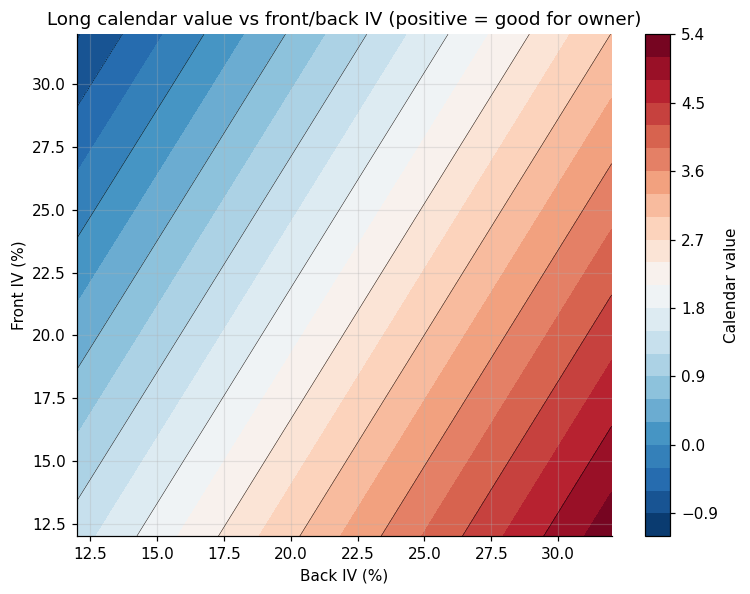

In [12]:
# Sensitivity: vary front IV and back IV independently
fronts = np.linspace(0.12, 0.32, 30)
backs  = np.linspace(0.12, 0.32, 30)
Z = np.zeros((len(fronts), len(backs)))
for i, fv in enumerate(fronts):
    for j, bv in enumerate(backs):
        legs = [Leg(-1, "C", 100, 1/12, fv),
                Leg(+1, "C", 100, 3/12, bv)]
        Z[i,j] = pos_price(legs, 100, 0.04, 0)

plt.figure(figsize=(7, 5.5))
plt.contourf(backs*100, fronts*100, Z, 20, cmap="RdBu_r")
plt.colorbar(label="Calendar value")
plt.contour(backs*100, fronts*100, Z, 10, colors="k", linewidths=0.3)
plt.xlabel("Back IV (%)"); plt.ylabel("Front IV (%)")
plt.title("Long calendar value vs front/back IV (positive = good for owner)")
plt.tight_layout(); plt.show()


You want **front IV down and back IV up** to make money — i.e. you want
the *term structure to steepen* (long-dated richer relative to short-dated).
This is why calendars are popular before earnings or scheduled events: front IV
is inflated; you sell that and buy back the (cheaper-relative) long-dated wing.

**Diagonals** combine this term-structure play with a directional view. E.g. sell
front ATM, buy back-month OTM = "I want spot to drift up but slowly" + "long vol
term structure." Diagonal is the swiss army knife — almost any view can be
expressed as one.


## 6. Risk reversals & seagulls

These are **skew trades**. A risk reversal is `long call + short put` (or the
opposite). Net delta is strongly positive (or negative), but the key is what it
says about *skew*.

If 25-delta puts trade at 24 vol and 25-delta calls trade at 18 vol (typical
equity skew), then **selling the put to fund the call** is selling rich vol to
buy cheap vol. The position has near-zero net premium and a strongly bullish
delta — popular as a directional expression that's "self-financing."

Risk: short gamma on the downside (you sold the put) is exactly where realized
vol explodes if things go wrong. RRs blow up in tail events.

**Seagull** = risk reversal + one extra wing. E.g. `long call + short put +
short higher call`. You give up upside above the short call to make the
structure **cheaper or a credit**. Common for hedging programs: "I want long
exposure for free, and I'm willing to cap my upside."


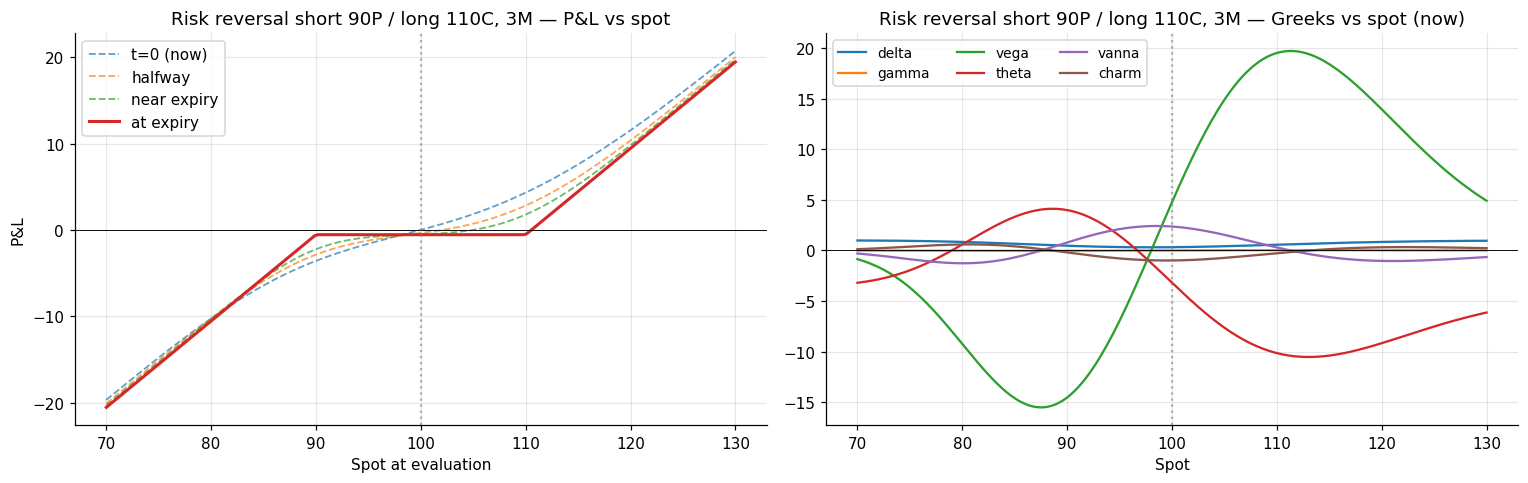

At S=100: cost=+0.559  delta=+0.325  gamma=+0.0096  vega=+4.781  theta=-3.191  vanna=+2.3717  charm=-0.9869


In [13]:
# Risk reversal: short 90P, long 110C (3M)
plot_structure([Leg(-1, "P",  90, 0.25, 0.20),
                Leg(+1, "C", 110, 0.25, 0.20)],
               S_range=(70, 130), title="Risk reversal short 90P / long 110C, 3M")


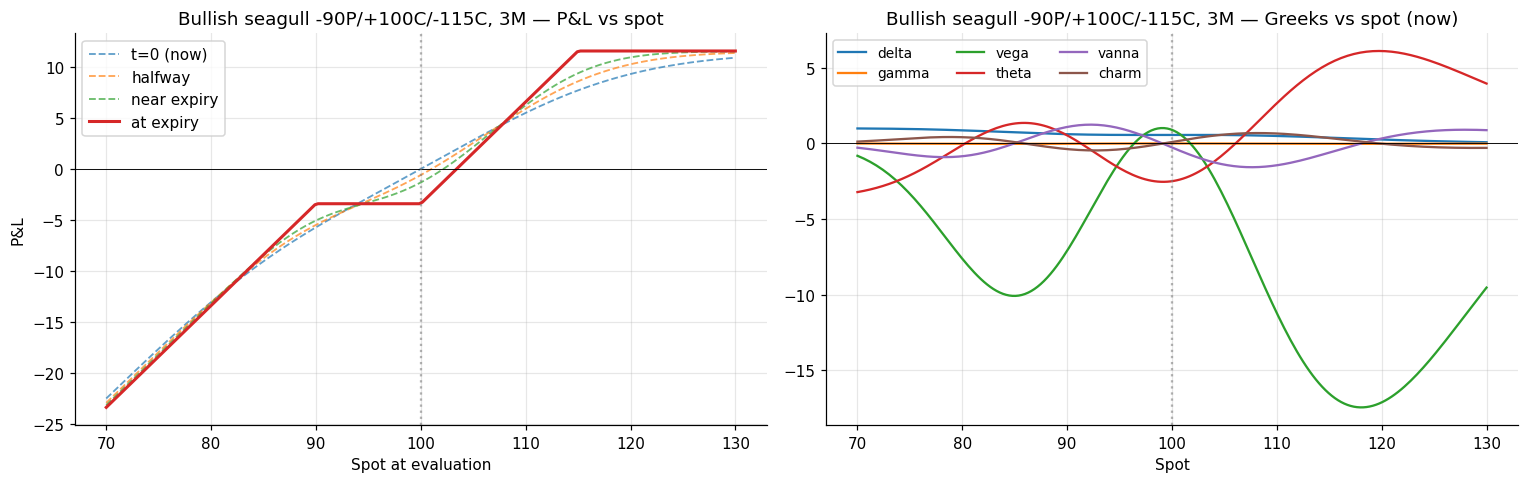

At S=100: cost=+3.416  delta=+0.568  gamma=+0.0018  vega=+0.897  theta=-2.494  vanna=-0.2661  charm=+0.0993


In [14]:
# Bullish seagull: short 90P + long 100C + short 115C
plot_structure([Leg(-1, "P",  90, 0.25, 0.20),
                Leg(+1, "C", 100, 0.25, 0.20),
                Leg(-1, "C", 115, 0.25, 0.20)],
               S_range=(70, 130), title="Bullish seagull -90P/+100C/-115C, 3M")


Notice the seagull P&L profile: limited downside risk floor at the short
put strike, capped upside at the short call. It's essentially a "collar around a
bull spread" or "bull spread financed by selling a put." Used heavily in commodity
producer hedging — a refiner who's structurally long crack spreads might run
bearish seagulls on crude.

**Skew sensitivity** — the value of a risk reversal is directly readable as
price-of-skew. If you observe market skew steepening, your long-call-short-put
RR gets more valuable even at constant spot and ATM vol.


## 7. Volatility strategies: straddles & strangles

Three flavors of "I want to bet on vol, not direction":

1. **Long straddle** = long ATM call + long ATM put. **Long gamma, long vega**.
   You're betting realized vol > implied. Bleeds theta hard.
2. **Long strangle** = long OTM call + long OTM put. Cheaper than straddle,
   needs bigger move to pay. Same Greek signs, smaller magnitudes.
3. **Short straddle/strangle** = the opposite. Short vol, short gamma, short
   vega, **positive theta**. The "I get paid for taking pain" trade.

**Critical mental model**: a straddle's P&L is approximately
`Gamma * (move)^2 / 2 - Theta * dt`. You pay theta daily; you collect gamma P&L
proportional to the *square* of moves. The breakeven move per day is
`sqrt(2 * theta / gamma) ≈ S * sigma_implied / sqrt(252)`. Realized vol > implied
→ long straddle makes money on average.


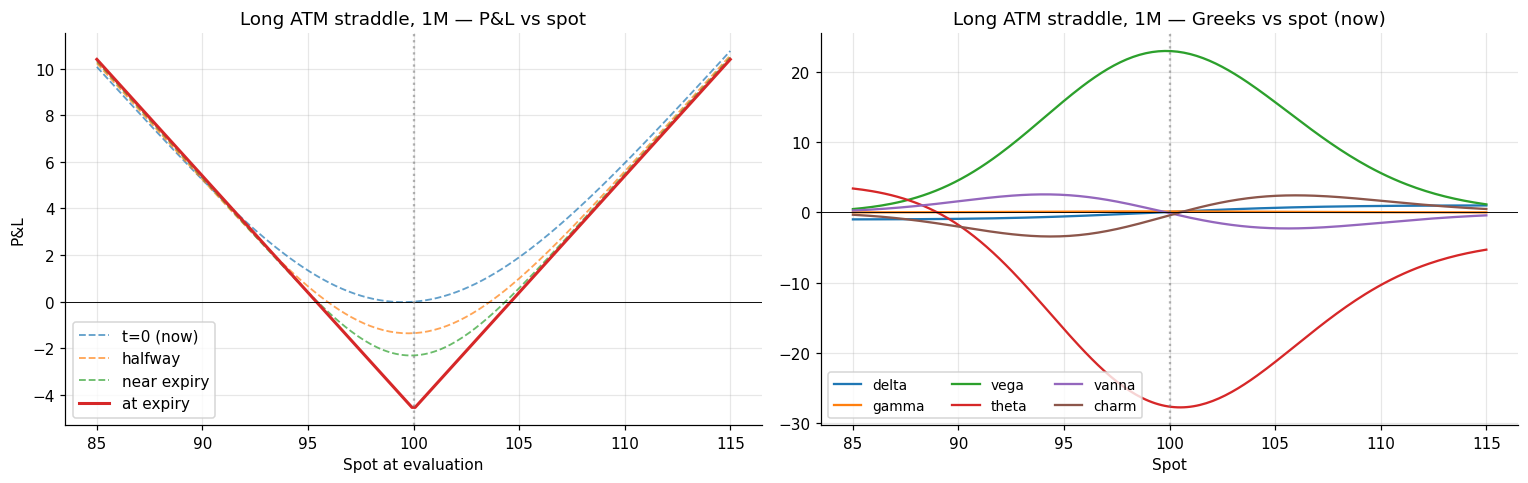

At S=100: cost=+4.606  delta=+0.069  gamma=+0.1377  vega=+22.947  theta=-27.628  vanna=-0.1147  charm=-0.4130


In [15]:
# Long ATM straddle, 1M
plot_structure([Leg(+1, "C", 100, 1/12, 0.20),
                Leg(+1, "P", 100, 1/12, 0.20)],
               S_range=(85, 115), title="Long ATM straddle, 1M")


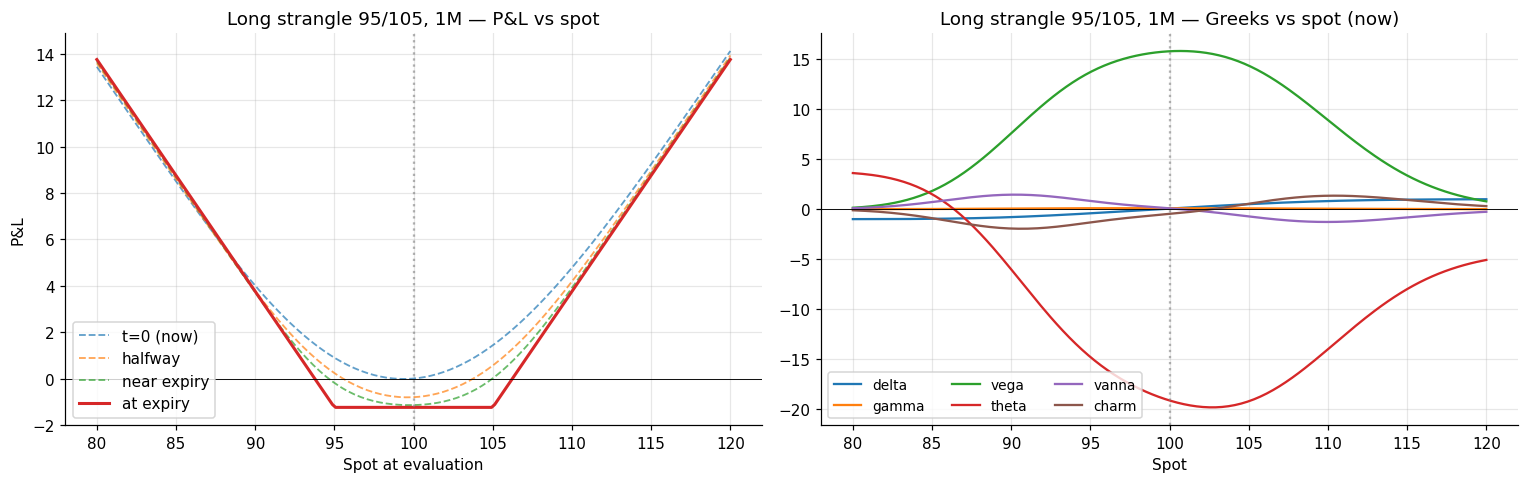

At S=100: cost=+1.244  delta=+0.059  gamma=+0.0948  vega=+15.797  theta=-19.144  vanna=+0.0836  charm=-0.4795


In [16]:
# Long strangle 95P/105C, 1M
plot_structure([Leg(+1, "P", 95,  1/12, 0.20),
                Leg(+1, "C", 105, 1/12, 0.20)],
               S_range=(80, 120), title="Long strangle 95/105, 1M")


**How to choose between them when expressing a vol view:**

| If you think... | Use |
|---|---|
| IV is low, big move coming, don't know direction | Long straddle |
| Same but want cheaper structure, willing to need bigger move | Long strangle |
| IV is rich, market will chop in a range | Short strangle (with wings → iron condor) |
| Specific event date with known IV term inflation | Calendar/diagonal across the event |
| IV is rich AND skew is rich on one side | Risk reversal that sells the rich side |
| Want pure vol exposure with no skew/delta cleanliness | Variance swap or vol swap (if available) |

**Realized-vs-implied — the trade behind the trade.** When you go long gamma,
you're implicitly forecasting `realized_vol > implied_vol`. The classic
backtest: long ATM straddle delta-hedged daily. Your P&L is approximately
`integral( 0.5 * Gamma_$ * (sigma_realized^2 - sigma_implied^2) dt )`.

If you want, the backtest skeleton from your existing GEX/realized-vs-implied
work plugs right in here.


## 8. Higher-order Greeks: charm, vanna, vomma, speed, color

The first-order Greeks tell you *exposure*. The second-order ones tell you *how
that exposure changes* — and in real trading, that's where the money is.

### Charm: dDelta/dT
Your delta drifts as time passes, even at constant spot. For an OTM call,
delta drips toward zero as expiry approaches; for an ITM call, it drifts toward
1. **Why it matters**: if you're delta-hedged at Friday close and you do nothing
over the weekend, by Monday open your delta is different. Charm tells you by
how much. Big for **Friday-to-Monday hedging on short-dated books** — and
heavily on dealer GEX work, which you already know.

### Vanna: dDelta/dsigma = dVega/dS
When vol moves, the delta of OTM options moves a lot. Vanna is asymmetric on
puts vs calls and is responsible for the "delta swings when VIX pops" phenomenon.
**Why it matters**: a vol shock changes your delta. If you're running a short-vol
book and vol spikes, you suddenly have a directional exposure you didn't have
five minutes ago. Vanna is also the leading-order term in the *vanna-volga*
pricing approach for FX options.

### Vomma (Volga): d²V/dsigma²
The vega-of-vega. Tells you how vega itself moves as vol moves. Convex in vol.
**Why it matters**: long OTM options are long vomma — they win disproportionately
when vol spikes. This is why "long tails" works: not just long vega, but
*convex* in vega.

### Speed: dGamma/dS
Gamma changes as spot moves. Speed matters when spot moves a lot relative to
strike spacing — your gamma profile reshapes.

### Color: dGamma/dT
Gamma changes as time passes. Near-expiry ATM options have gamma that
**explodes** as T → 0 (pin risk). Color quantifies that.

Visual: how the same options' Greeks evolve from `T=90d → T=1d` at constant
spot. This is the "what happens if I do nothing" exercise.


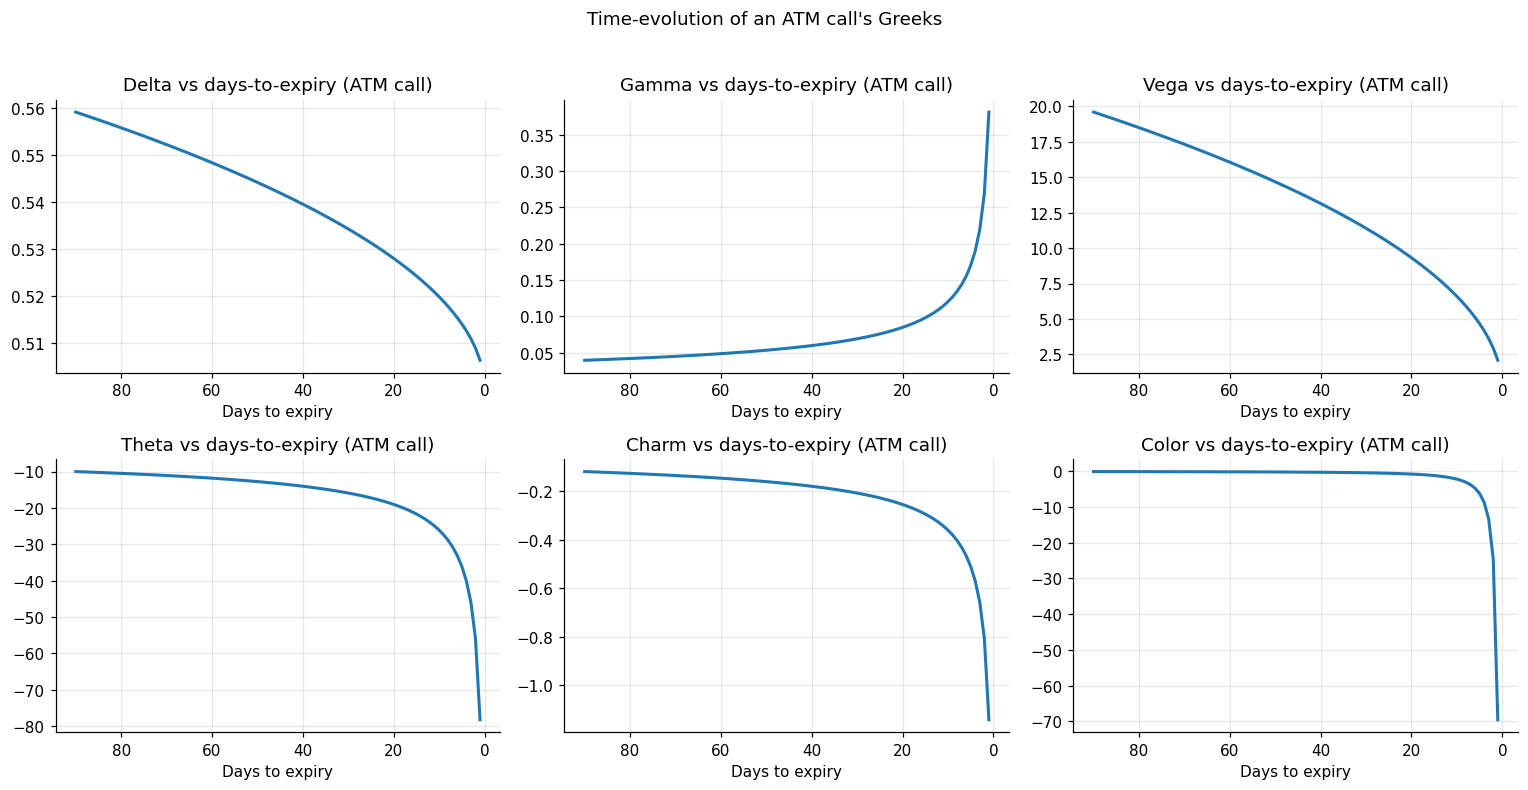

In [17]:
days = np.arange(1, 91)
S0, K, r, q, sigma = 100, 100, 0.04, 0.0, 0.20

rows = []
for d in days:
    T_ = d/365
    g = greeks(S0, K, T_, r, q, sigma, "C")
    g["days"] = d
    rows.append(g)
dfT = pd.DataFrame(rows)

fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for ax, key, name in zip(axes.flat,
                         ["delta","gamma","vega","theta","charm","color"],
                         ["Delta","Gamma","Vega","Theta","Charm","Color"]):
    ax.plot(dfT["days"], dfT[key], lw=2)
    ax.invert_xaxis()
    ax.set_title(f"{name} vs days-to-expiry (ATM call)")
    ax.set_xlabel("Days to expiry")
plt.suptitle("Time-evolution of an ATM call's Greeks", y=1.02)
plt.tight_layout(); plt.show()


Watch: **gamma and theta both explode as `T → 0` for ATM**. Charm spikes
hard in the last week. This is why **pin risk** is real on expiry day —
delta-hedging a near-expiry ATM book is a continuous-rebalancing nightmare.

Practical takeaway for risk: when you look at a book's Greeks, the front-week
ATM strikes contribute most of the *change* in your exposure between any two
points in time — even if their first-order Greeks look reasonable.


## 9. Hedging in practice: delta-hedging a short straddle

Theory's nice; let's simulate it. Sell a 1-month ATM straddle at 20-vol implied.
Simulate spot under realized vol = 15% (good for short vol) and 25% (bad).
Delta-hedge daily. Decompose P&L into:

1. **Pure option P&L** = MTM change of the straddle
2. **Hedge P&L** = `delta_t * dS`
3. **Gamma-theta decomposition** = `0.5 * Gamma * dS² + Theta * dt`

The gamma-theta decomp is the cleanest way to see *why* short-vol traders
collect during quiet periods and bleed during volatile ones.


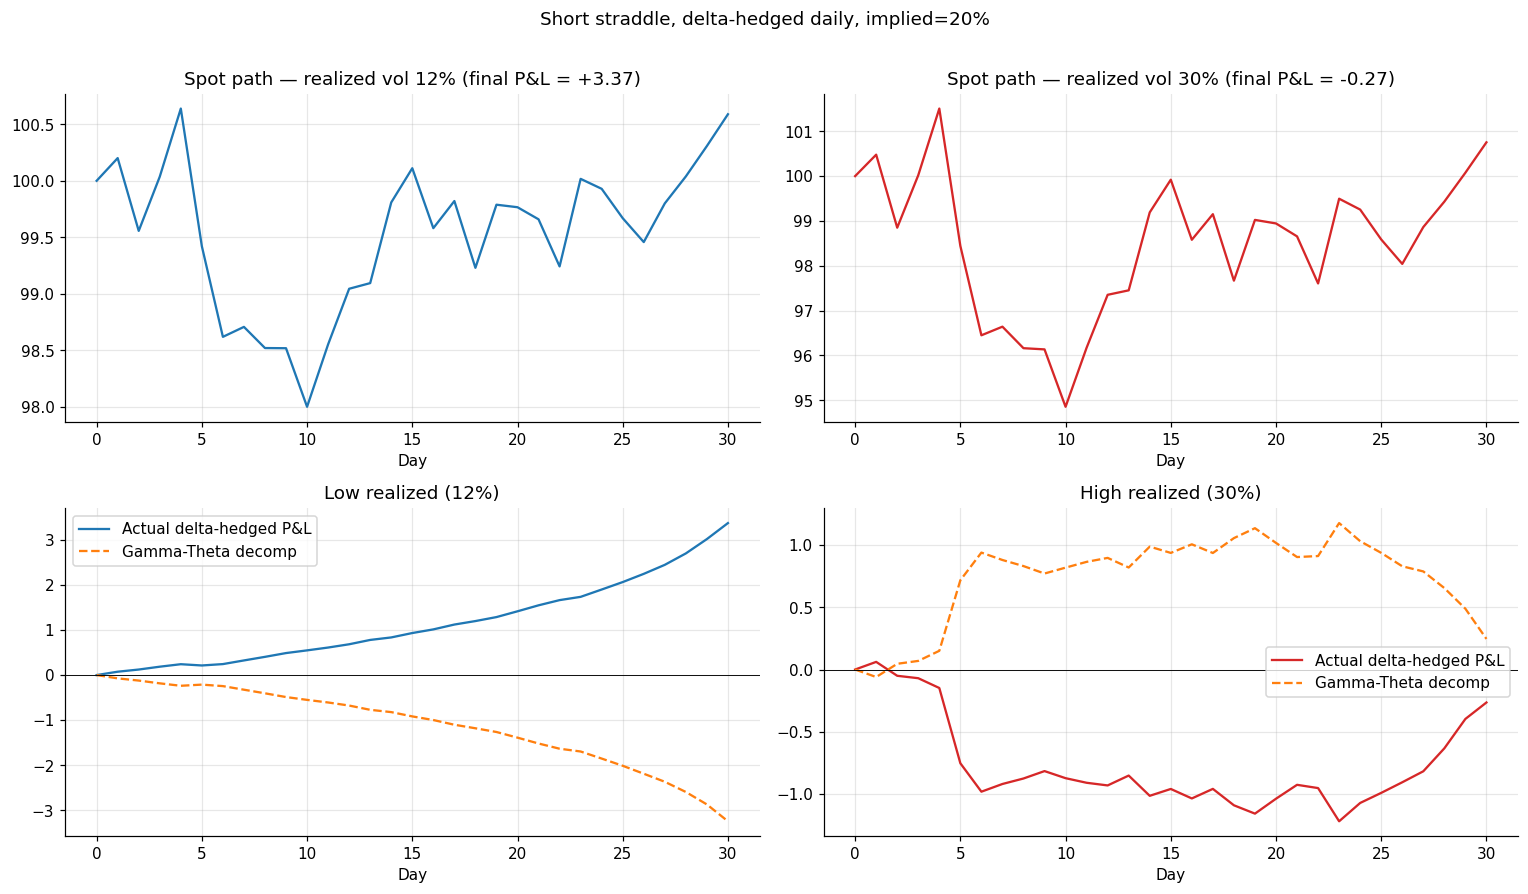

Premium received per side: ~4.57
Low-vol path final P&L:  +3.369
High-vol path final P&L: -0.265


In [18]:
def simulate_short_straddle(seed, sigma_realized, sigma_implied=0.20,
                              S0=100, T=30/365, n_steps=30, r=0.04, q=0.0):
    rng = np.random.default_rng(seed)
    dt = T / n_steps
    S = np.zeros(n_steps + 1); S[0] = S0
    for t in range(n_steps):
        z = rng.standard_normal()
        S[t+1] = S[t] * np.exp((r - q - 0.5*sigma_realized**2)*dt
                               + sigma_realized*np.sqrt(dt)*z)

    K = S0
    # we short 1 straddle at t=0 at implied vol
    short_legs = lambda T_: [Leg(-1, "C", K, T_, sigma_implied),
                              Leg(-1, "P", K, T_, sigma_implied)]
    pv0 = pos_price(short_legs(T), S0, r, q)  # cash we receive (negative number)
    cash = -pv0   # we received premium

    delta_hedge = 0.0
    pnl_path = [0.0]
    gamma_theta_pnl_path = [0.0]
    pnl_cum = 0.0
    gt_cum = 0.0

    for t in range(n_steps):
        T_left = T - t*dt
        T_next = T - (t+1)*dt
        S_now = S[t]; S_next = S[t+1]

        g_now = pos_greeks(short_legs(T_left), S_now, r, q)
        delta_pos = g_now["delta"]
        # Hedge: we hold -delta_pos shares to neutralize.
        target_shares = -delta_pos
        d_shares = target_shares - delta_hedge
        cash -= d_shares * S_now
        delta_hedge = target_shares

        # advance to next step
        pv_now  = pos_price(short_legs(T_left), S_now,  r, q)
        pv_next = pos_price(short_legs(max(T_next,1e-9)), S_next, r, q)
        d_pv   = pv_next - pv_now
        d_hedge = delta_hedge * (S_next - S_now)
        pnl_step = d_pv + d_hedge
        pnl_cum += pnl_step
        pnl_path.append(pnl_cum)

        # gamma-theta proxy P&L (for the short position)
        gt_step = 0.5 * g_now["gamma"] * (S_next - S_now)**2 + g_now["theta"] * dt
        # this is the *long* approx; we are short, so flip
        gt_step = -gt_step
        gt_cum += gt_step
        gamma_theta_pnl_path.append(gt_cum)

    # final unwind: close hedge, close options at T=0 (intrinsic)
    intrinsic = max(S[-1]-K, 0) + max(K-S[-1], 0)
    final_close = pos_price(short_legs(1e-9), S[-1], r, q)  # ~ -intrinsic
    cash += delta_hedge * S[-1]   # close hedge
    cash += final_close           # buy back the short straddle (negative outflow)

    return dict(S=S, pnl_path=np.array(pnl_path),
                gt_path=np.array(gamma_theta_pnl_path),
                final_pnl=cash, premium_received=-pv0)

# Two paths: realized below implied (good), realized above implied (bad)
good = simulate_short_straddle(seed=42, sigma_realized=0.12)
bad  = simulate_short_straddle(seed=42, sigma_realized=0.30)

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes[0,0].plot(good["S"]); axes[0,0].set_title(
    f"Spot path — realized vol 12% (final P&L = {good['final_pnl']:+.2f})")
axes[0,0].set_xlabel("Day")
axes[0,1].plot(bad["S"], color="C3"); axes[0,1].set_title(
    f"Spot path — realized vol 30% (final P&L = {bad['final_pnl']:+.2f})")
axes[0,1].set_xlabel("Day")

axes[1,0].plot(good["pnl_path"], label="Actual delta-hedged P&L")
axes[1,0].plot(good["gt_path"], "--", label="Gamma-Theta decomp")
axes[1,0].axhline(0, color="k", lw=0.6); axes[1,0].set_title("Low realized (12%)")
axes[1,0].set_xlabel("Day"); axes[1,0].legend()

axes[1,1].plot(bad["pnl_path"], label="Actual delta-hedged P&L", color="C3")
axes[1,1].plot(bad["gt_path"], "--", label="Gamma-Theta decomp", color="C1")
axes[1,1].axhline(0, color="k", lw=0.6); axes[1,1].set_title("High realized (30%)")
axes[1,1].set_xlabel("Day"); axes[1,1].legend()

plt.suptitle("Short straddle, delta-hedged daily, implied=20%", y=1.01)
plt.tight_layout(); plt.show()

print(f"Premium received per side: ~{good['premium_received']:.2f}")
print(f"Low-vol path final P&L:  {good['final_pnl']:+.3f}")
print(f"High-vol path final P&L: {bad['final_pnl']:+.3f}")


**What you should see** (modulo path randomness):

- Low-realized path: gamma-theta decomp tracks actual P&L closely, both
  positive. You collected theta faster than gamma cost you.
- High-realized path: both go negative. Gamma bleed > theta carry. Your
  hedging breaks even on a *path-by-path* basis only if realized ≈ implied.

This is the volatility risk premium ("VRP") in mechanics: on average implied >
realized, so short-vol strategies edge positive — but with **fat left tails**.
The path is everything, especially the *clustering* of moves (volatility of
volatility). Static Greek snapshots hide that.

**The vanna-charm overlay** — in dealer flow analysis (your GEX work), when
dealers are short gamma and spot moves, their delta-hedging amplifies the move.
But even without spot moving, charm (delta bleed) forces hedging flows, and
vanna (delta change from vol moves) does the same when IV moves. The same
math you wrote in your multi-expiry GEX notebook applies here.


## 10. Choosing a structure for a given view

A working playbook. The two questions before structuring anything:

**Q1: What is your view, decomposed?**
- Direction (delta) — bullish / bearish / neutral
- Magnitude (gamma) — small move / big move / no move
- Vol path (vega) — IV up / down / unchanged
- Skew (vanna/RR) — skew steepening / flattening
- Term structure (calendar) — front rich / back rich / flat
- Event (specific date)

**Q2: How are you paid? Premium received or paid? Theta sign? Capped or
uncapped loss?**

### Lookup table

| View | Best structures | Why |
|---|---|---|
| Bullish, moderate move, IV low | Long call, bull call spread, call calendar | Pay for direction + cheap optionality |
| Bullish, moderate move, IV high | Bull put spread, risk reversal | Sell rich premium to express view |
| Bullish, big move expected | Long call, OTM call ratio | Convexity is the point |
| Mildly bullish, range-bound up | Bull put credit spread, call calendar | Collect theta with bullish lean |
| Strongly bullish, low cost | Risk reversal, seagull | Self-financing via skew |
| Neutral, expect range | Iron condor, short strangle, fly | Pure theta/short-vol |
| Neutral, expect big move | Long straddle, long strangle | Long realized vol |
| Bearish, IV low | Long put, bear put spread | Same as bullish reversed |
| Bearish, IV high | Bear call credit, risk reversal short | Sell call skew |
| Event with known date, vol crush expected | Short fly/condor around event, sell calendar | Term-structure play |
| Event with known date, big move expected | Long calendar (sell back, buy front) — i.e. *reverse* calendar | Front gamma is what you want |
| Hedging a long underlying portfolio | Collar (long put + short call), put spread, seagull | Cheap protection with capped givenup |
| Skew steepening view | Long risk reversal (long puts, short calls) | Direct skew bet |

### A worked example you'll recognize

You think Brent will trade in a $5 range over the next 3 weeks, the OPEC+ meeting
won't move it much, but 1-week ATM IV is pricing 40 and 2-month is pricing 28.
Front IV is rich relative to back IV (term structure inverted-ish).

- **View decomposed**: low realized in the front, term structure should
  normalize (front falls relative to back).
- **Structure**: short front straddle hedged with long back-month wings — i.e.
  a **calendar straddle** or a **double calendar**.
- **Greeks**: short front gamma (good if range-bound), long back vega (good if
  term structure normalizes by back vol rising or front falling).
- **Risk**: huge move in the next week blows up the short front straddle even
  with back-month protection. Size accordingly.

This kind of structuring — pick the legs that *match the Greek profile of your
decomposed view* — is the entire game.

### A short list of pitfalls

1. **Don't trade direction with structures that have unfavorable Greeks.**
   Short put for a bullish view is fine in isolation, but you're short gamma at
   exactly the strike you'd be unhappy at — assess your max-loss path.
2. **Don't sell vol blind to skew.** Selling a put at 18-delta is very different
   from selling a call at 18-delta in equities — implied vols differ.
3. **Calendars need spot to behave near the strike at front expiry**, or they
   morph into directional bets you didn't intend.
4. **Watch charm on Fridays and overnight.** A "delta-neutral" book at
   Friday 4pm might be ±5% delta by Monday open just from charm.
5. **Pin risk is real.** Don't carry large near-expiry ATM positions you can't
   actively manage.
6. **Vega is not vega.** A vega number is meaningless without knowing where on
   the term structure it sits. Front-month vega and back-month vega behave
   nothing alike in a vol spike.

### What's next, if you want to extend this notebook

- Bring your own IV surface in (term structure + skew) and reprice these
  structures with strike-and-expiry-specific vol instead of flat 20.
- Add a Monte Carlo engine that respects vol clustering (GARCH or stochastic vol
  like Heston) — short-vol P&L distributions look much fatter-tailed than the
  log-normal world suggests.
- Hook this up to your `realized vs implied` backtest skeleton — feed each
  delta-hedged structure through and compare Sharpes.
- Build a "view → structure" recommender: input desired Greek signs and
  magnitudes, output the cheapest leg-combo that matches.
